In [1]:
import sys
import os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

import h5py
from H2Crop.H2Crop import H2Crop
import matplotlib.pyplot as plt
import numpy as np
from utils import visualize_sample, plot_spectral_signatures_H2Crop

In [2]:
H2Crop_dataset = H2Crop()

In [3]:
data = H2Crop_dataset.get_random_h5_sample()

if data:
    print(f"\nExtracted Array Shapes:")
    print(f" - Hyperspectral: {data['hyperspectral'].shape}")
    print(f" - Multispectral: {data['multispectral'].shape}")
    print(f" - Labels:        {data['labels'].shape}")
    print(f" - Priors:        {data['prior'].shape}")


Extracted Array Shapes:
 - Hyperspectral: (218, 64, 64)
 - Multispectral: (12, 10, 192, 192)
 - Labels:        (4, 192, 192)
 - Priors:        (4, 192, 192)


In [ ]:
list_files = H2Crop_dataset.get_file_list(from_train=False, limit=1600)
data = H2Crop_dataset.load_h5_data(file_list=list_files, keep_prior=False, data_type="multispectral", detail_layer=0, static=True)

# for sample in data:
#     print(f"\nExtracted Array Shapes:")
#     print(f" - Hyperspectral: {sample['hyperspectral'].shape}")
#     print(f" - Labels:        {sample['labels'].shape}")
#     print('\n')

Successfully sampled 1600 file IDs.


In [ ]:
def check_ram_usage(data, RAM=1):
    tot_bytes = 0

    for sample in data:
        for key,value in sample.items():
            if hasattr(value, 'nbytes'):
                tot_bytes += value.nbytes
    
    RAM_bytes = RAM * 1024 * 1024 * 1024

    print(f'RAM usage (bytes): {tot_bytes} | {RAM_bytes}')
    print(f'RAM usage (%): {round((tot_bytes * 100) / (RAM_bytes), 2)}%')

In [ ]:
check_ram_usage(data=data, RAM=16)

RAM usage (bytes): 2916352000 | 17179869184
RAM usage (%): 16.98%


# PLOT IMAGES

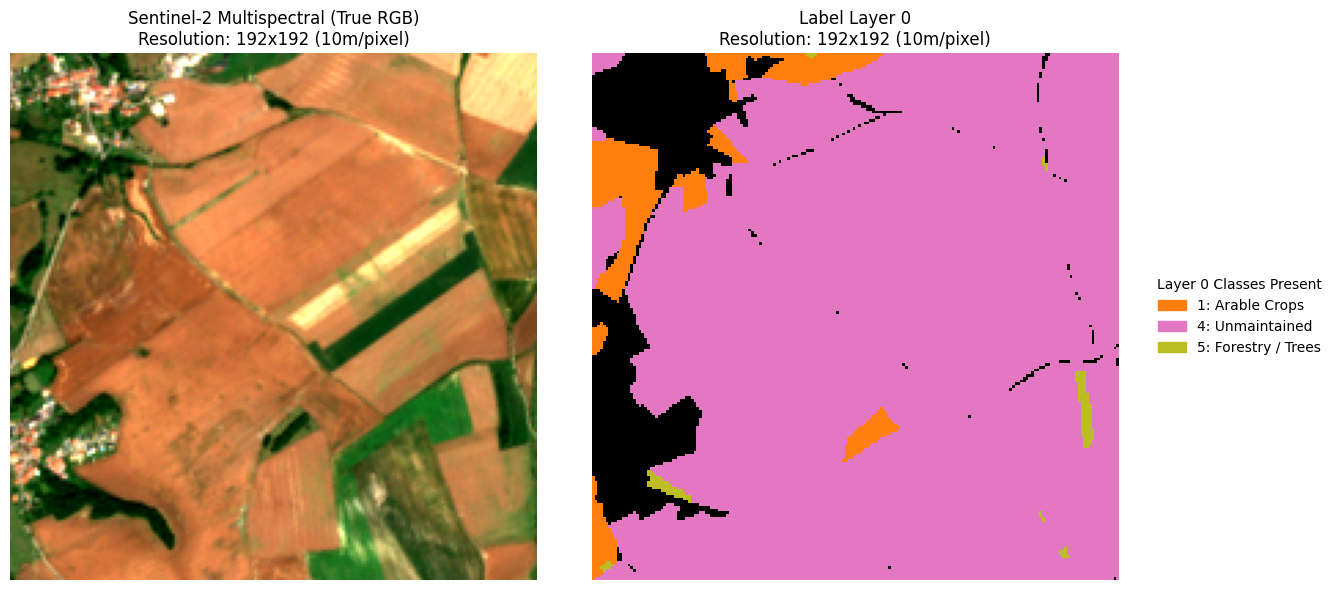

In [ ]:
# Assuming you already instantiated your H2Crop class and loaded a sample:
loader = H2Crop()
my_sample = loader.get_random_h5_sample(static=True)
visualize_sample(my_sample, detail_layer=0, classes_to_drop=[0])

# ANALYSIS SPECTRAL SIGNATURES

## Taxonomy 0

In [ ]:
file_list_path = 'results_2_H2Crop/baseline_layer_0_drop_0_3/file_sample_list.txt'

# Read File
def read_file():
    
    with open(file_list_path, "r") as f:
        file_list = f.read().splitlines()
        return file_list

file_list = read_file()

for i in range(0,5):
    print(file_list[i])

# Loader
loader = H2Crop()

20230624T120954Z_001_x1152_y1024_T30UVV
20220613T112229Z_005_x256_y640_T32ULU
20220621T113005Z_008_x192_y128_T30UYU
20220616T110157Z_027_x1024_y320_T31TFL
20220616T110055Z_013_x448_y704_T32ULV



Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 300 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


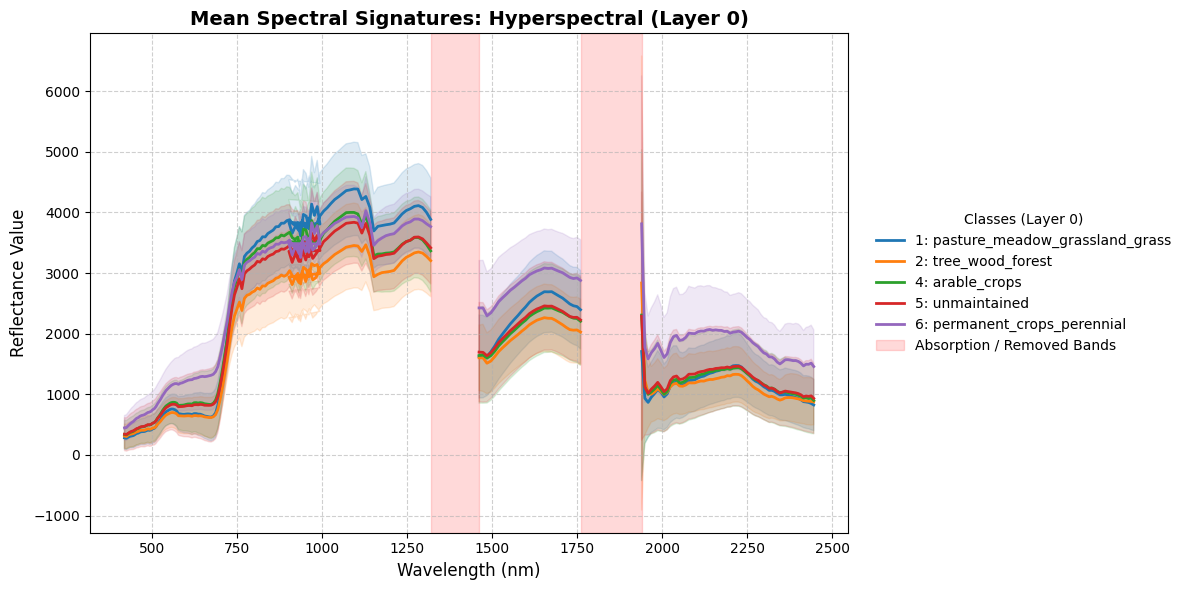


Extracting Spectral Signatures for MULTISPECTRAL...
Successfully loaded 300 files into memory.
-> Modality kept: 'multispectral'. Priors kept: False.


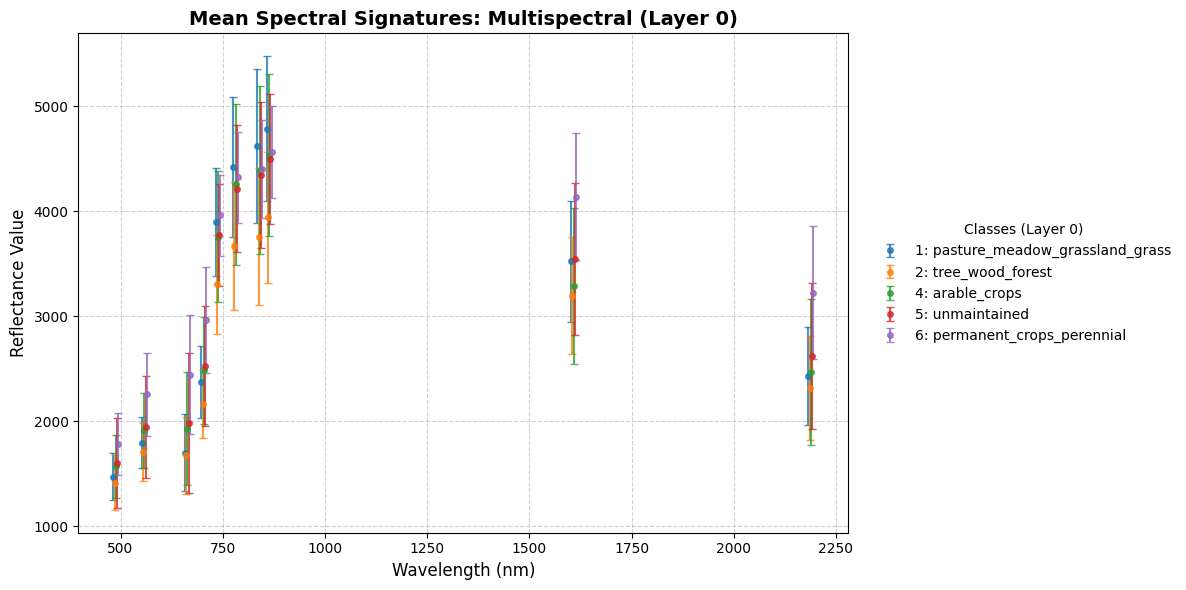

In [ ]:
plot_spectral_signatures_H2Crop(
    loader=loader,
    file_list=file_list,
    modality="hyperspectral",
    detail_layer=0,
    classes_to_show=[1,2,4,5,6]
)

plot_spectral_signatures_H2Crop(
    loader=loader,
    file_list=file_list,
    modality="multispectral",
    detail_layer=0,
    classes_to_show=[1,2,4,5,6]
)

## Taxonomy 3

Create file samples

In [4]:
from_train = False
limit = 600
save_result_dir = '../H2Crop'

loader = H2Crop()
file_sample_list = loader.get_file_list(from_train=from_train,
                                            limit=limit)
print("Saving file_sample_list...")

os.makedirs(save_result_dir, exist_ok=True)
with open(os.path.join(save_result_dir, "file_sample_list.txt"), "w") as f:
    for file_name in file_sample_list:
        f.write(file_name + '\n')
    
print("file sample list succesfully saved")

Successfully sampled 600 file IDs.
Saving file_sample_list...
file sample list succesfully saved


In [5]:
file_sample_path = '../H2Crop/file_sample_list.txt'

# Read File
def read_file():
    
    with open(file_sample_path, "r") as f:
        file_list = f.read().splitlines()
        return file_list

file_list = read_file()

for i in range(0,5):
    print(file_list[i])

# Loader
loader = H2Crop()

20220616T110055Z_013_x1088_y448_T31UGQ
20220628T111310Z_032_x896_y192_T31TFJ
20220616T110139Z_023_x832_y128_T31TFM
20230624T121003Z_003_x1152_y1216_T30UVU
20220616T110135Z_022_x576_y832_T31TFM


In [9]:
sub_1 = [8, 23, 11, 56]
sub_2 = [13, 30, 38, 53, 61]
sub_3 = [1, 2, 10, 17]
sub_4 = [29, 50, 64, 76]


Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 600 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


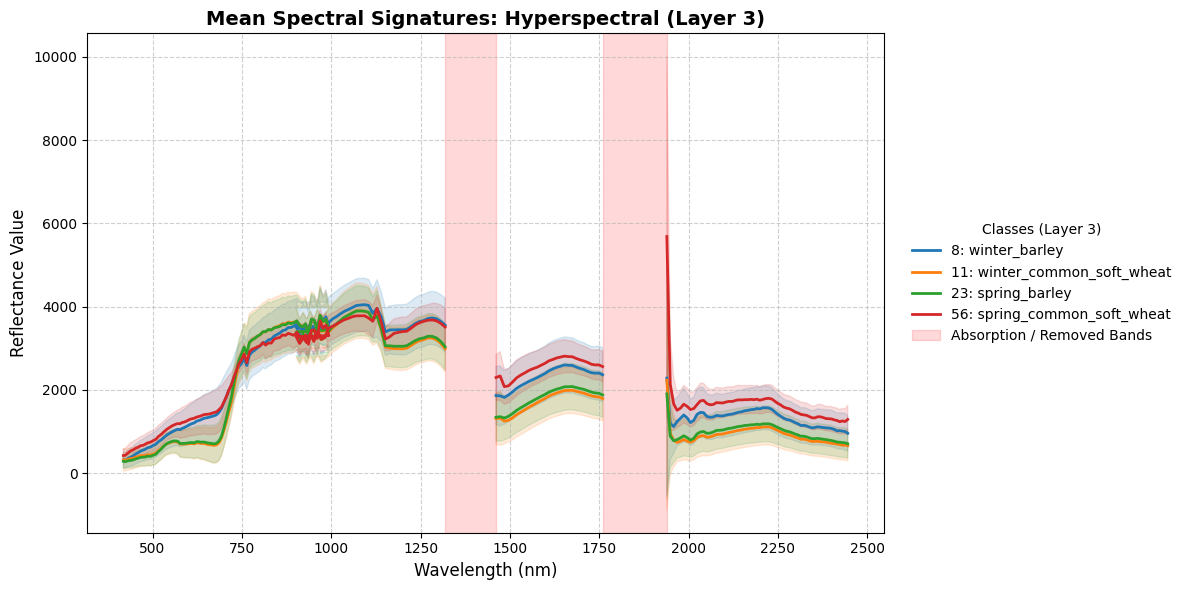


Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 600 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


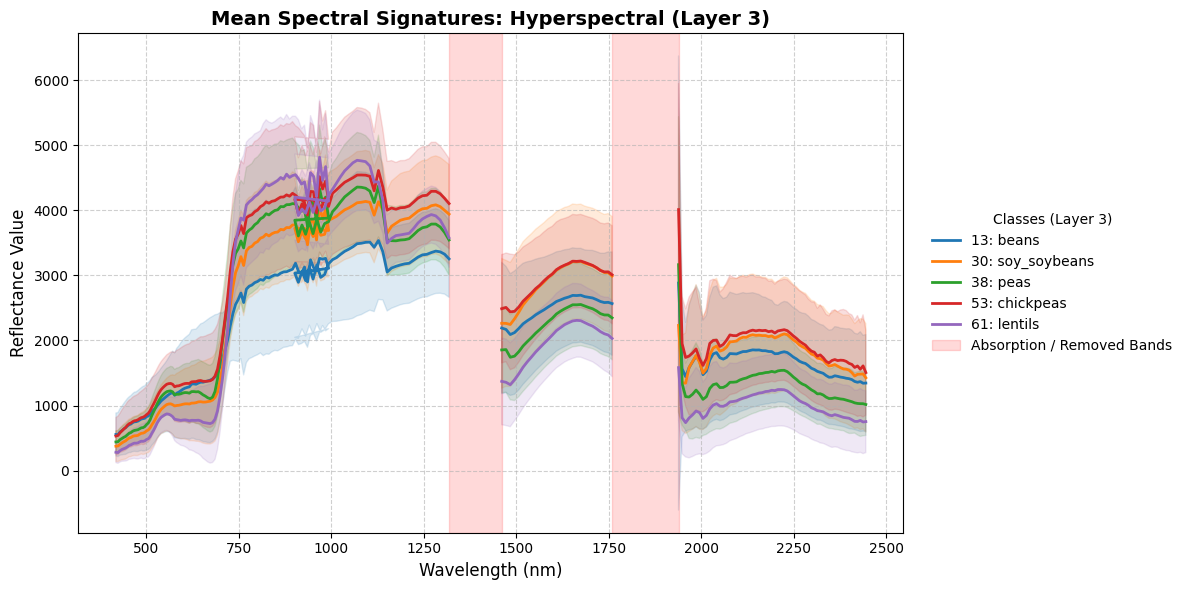


Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 600 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


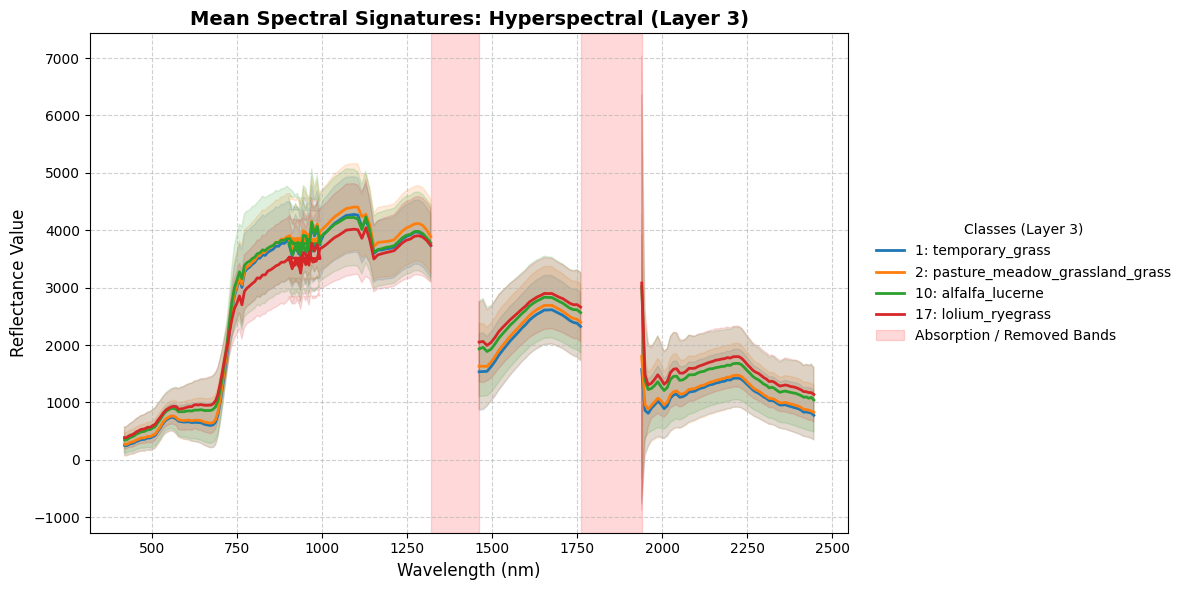


Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 600 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


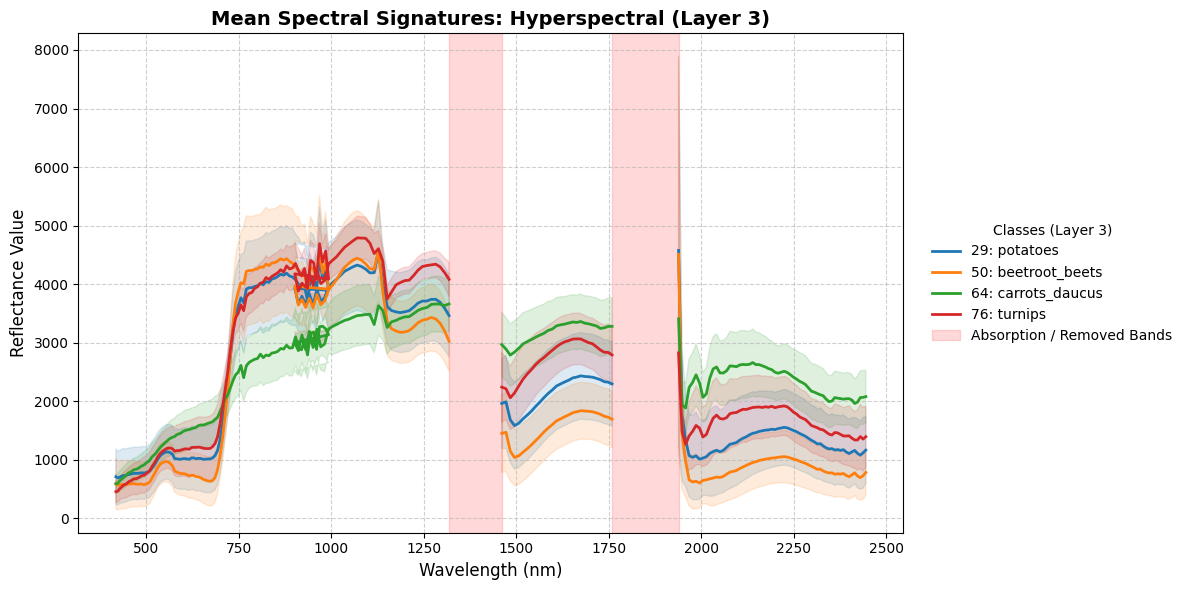

In [10]:
subsets = [sub_1, sub_2, sub_3, sub_4]

for subset in subsets:
    plot_spectral_signatures_H2Crop(
        loader=loader,
        file_list=file_list,
        modality="hyperspectral",
        detail_layer=3,
        classes_to_show=subset
    )
